In [1]:

!pip install unsloth


     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ------------ --------------------------- 2.4/7.8 MB 11.2 MB/s eta 0:00:01
     --------------------- ------------------ 4.2/7.8 MB 10.1 MB/s eta 0:00:01
     -------------------------------- ------- 6.3/7.8 MB 9.6 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 9.2 MB/s eta 0:00:00


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\dean0\\AppData\\Local\\Temp\\pip-install-i44j3j36\\xformers_edff5b55a07247afb78a2167d1b23ee7\\third_party\\flash-attention\\csrc\\composable_kernel\\client_example\\24_grouped_conv_activation\\grouped_convnd_bwd_data_bilinear\\grouped_conv_bwd_data_bilinear_residual_fp16.cpp'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



  Cloning https://github.com/unslothai/unsloth.git to c:\users\dean0\appdata\local\temp\pip-install-fm7h7km4\unsloth_c0e7b03d0eed4f488633945948e3e647
  Resolved https://github.com/unslothai/unsloth.git to commit 79a2112ca4a775ce0b3cb75f5074136cb54ea6df
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/992.0 kB ? eta -:--:--
   --------------------------------------- 992.0/992.0 kB 48.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------- ----------------------- 4.2/

  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git 'C:\Users\dean0\AppData\Local\Temp\pip-install-fm7h7km4\unsloth_c0e7b03d0eed4f488633945948e3e647'


In [3]:
!pip install --upgrade pip
!pip install "unsloth[cu121-torch240] @ git+https://github.com/unslothai/unsloth.git"

  Cloning https://github.com/unslothai/unsloth.git to c:\users\dean0\appdata\local\temp\pip-install-okc2_q0d\unsloth_a8a493f9d02a4ef78d8dd83f6e175177
  Resolved https://github.com/unslothai/unsloth.git to commit 79a2112ca4a775ce0b3cb75f5074136cb54ea6df
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git 'C:\Users\dean0\AppData\Local\Temp\pip-install-okc2_q0d\unsloth_a8a493f9d02a4ef78d8dd83f6e175177'
ERROR: xformers-0.0.27.post2-cp312-cp312-manylinux2014_x86_64.whl is not a supported wheel on this platform.


In [11]:
from openai import OpenAI

client = OpenAI(
  base_url = "https://integrate.api.nvidia.com/v1",
  api_key = "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"
)

# Initialize history to store previous instructions
history = []

# Function to get drone navigation instructions
def get_drone_navigation_instructions(start, end, obstacles):
    # Prepare the prompt with the structured context
    prompt = (
        "You are an intelligent assistant helping a user navigate a drone from point A to point B while avoiding obstacles. "
        "Your role is to provide clear guidance and support for controlling the drone. You can generate movement instructions, "
        "suggest ways to avoid obstacles, and provide explanations for your suggestions. Your abilities include:\n"
        "- Navigation: Generate movement instructions based on given coordinates.\n"
        "- Obstacle avoidance: Suggest maneuvers to bypass obstacles.\n"
        "- Explanation: Justify your navigation suggestions.\n\n"
        
        "The drone operates in a 3D environment where it must navigate from a starting point to a destination while avoiding obstacles. "
        "The obstacles are fixed in the environment, and the drone can only move along the designated path. Be aware of the drone's current position and any obstacles it may encounter.\n\n"
        
        "When generating navigation instructions, you must adhere to the following commands:\n"
        "- move_to(x, y, z): Move the drone to the specified coordinates.\n"
        "- avoid(obstacle): Suggest ways to bypass a given obstacle.\n"
        "Ensure all responses are relevant to these commands and do not include extraneous information.\n\n"
        
        "Generate navigation instructions in the following format:\n"
        "- Instruction: [move_to(x, y, z)]\n"
        "- Justification: [explain why this move is necessary]\n\n"
        
        "Example Navigation Task:\n"
        "User: 'Navigate the drone from (0, 0, 0) to (10, 10, 0) while avoiding obstacles at [(2, 2, 0), (4, 4, 0), (6, 6, 0)]'\n"
        "Model Response:\n"
        "Instruction: move_to(3, 2, 0)\n"
        "Justification: 'This move is necessary to avoid the first obstacle.'\n\n"
        
        f"You are navigating from point {start} to point {end}. "
        f"Your task is to plot the shortest route avoiding the following obstacles: {obstacles}."
    )

    # Add the current prompt to history
    history.append(prompt)

    # Create a chat completion request
    completion = client.chat.completions.create(
        model="meta/llama-3.1-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        top_p=0.7,
        max_tokens=1024,
        stream=True
    )

    # Collect the instructions from the response
    instructions = ""
    for chunk in completion:
        if chunk.choices[0].delta.content is not None:
            instructions += chunk.choices[0].delta.content

    return instructions

# Function to process the navigation output
def process_navigation_output(navigation_output):
    # Separate the output into instructions and justifications
    lines = navigation_output.strip().split("\n")
    path_instructions = []
    justifications = []

    for line in lines:
        if line.startswith("Instruction:"):
            path_instructions.append(line.replace("Instruction: ", "").strip())
        elif line.startswith("Justification:"):
            justifications.append(line.replace("Justification: ", "").strip())

    return path_instructions, justifications

# Example usage
start_point = (0, 0, 0)  # Starting coordinates
end_point = (10, 10, 10)  # Ending coordinates
obstacle_list = [(2, 2, 2), (4, 4, 4), (6, 6, 5)]  # List of obstacles

# Get navigation instructions
navigation_instructions = get_drone_navigation_instructions(start_point, end_point, obstacle_list)

# Print the results
print("Navigation Instructions:")
print(navigation_instructions)

# Print the history of prompts
print("\nHistory of Prompts:")
for idx, item in enumerate(history):
    print(f"{idx + 1}: {item}")

ERROR: xformers-0.0.27.post2-cp312-cp312-manylinux2014_x86_64.whl is not a supported wheel on this platform.


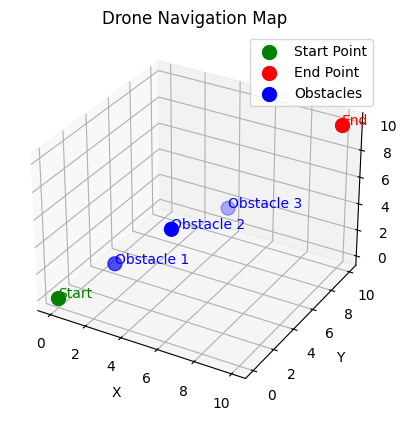

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the coordinates
start_point = (0, 0, 0)
end_point = (10, 10, 10)
obstacle_list = [(2, 2, 2), (4, 4, 4), (6, 6, 5)]

# Extract x, y, z coordinates for obstacles
obstacle_x = [obs[0] for obs in obstacle_list]
obstacle_y = [obs[1] for obs in obstacle_list]
obstacle_z = [obs[2] for obs in obstacle_list]

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot start and end points
ax.scatter(start_point[0], start_point[1], start_point[2], color='green', label='Start Point', s=100)
ax.scatter(end_point[0], end_point[1], end_point[2], color='red', label='End Point', s=100)

# Plot obstacles
ax.scatter(obstacle_x, obstacle_y, obstacle_z, color='blue', label='Obstacles', s=100)

# Add labels
ax.text(start_point[0], start_point[1], start_point[2], 'Start', color='green')
ax.text(end_point[0], end_point[1], end_point[2], 'End', color='red')
for i, (x, y, z) in enumerate(obstacle_list):
    ax.text(x, y, z, f'Obstacle {i+1}', color='blue')

# Set plot labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Drone Navigation Map')

# Show legend
ax.legend()

# Display the plot
plt.show()


In [14]:
!pip install triton

ERROR: Could not find a version that satisfies the requirement triton (from versions: none)
ERROR: No matching distribution found for triton
